In [1]:
### Changes: 
# max poly degree no longer necessary;
# HC param set to about 60
# input mode truncation set to d_i = 20
# changed Jac(a,a) to a = n**2, capturing 95% energy 
# do = 150. See spectral data and plot 
# anisotorpy weights set to (1,0.01) linearly decaying; leads to N_{eff} = 5046

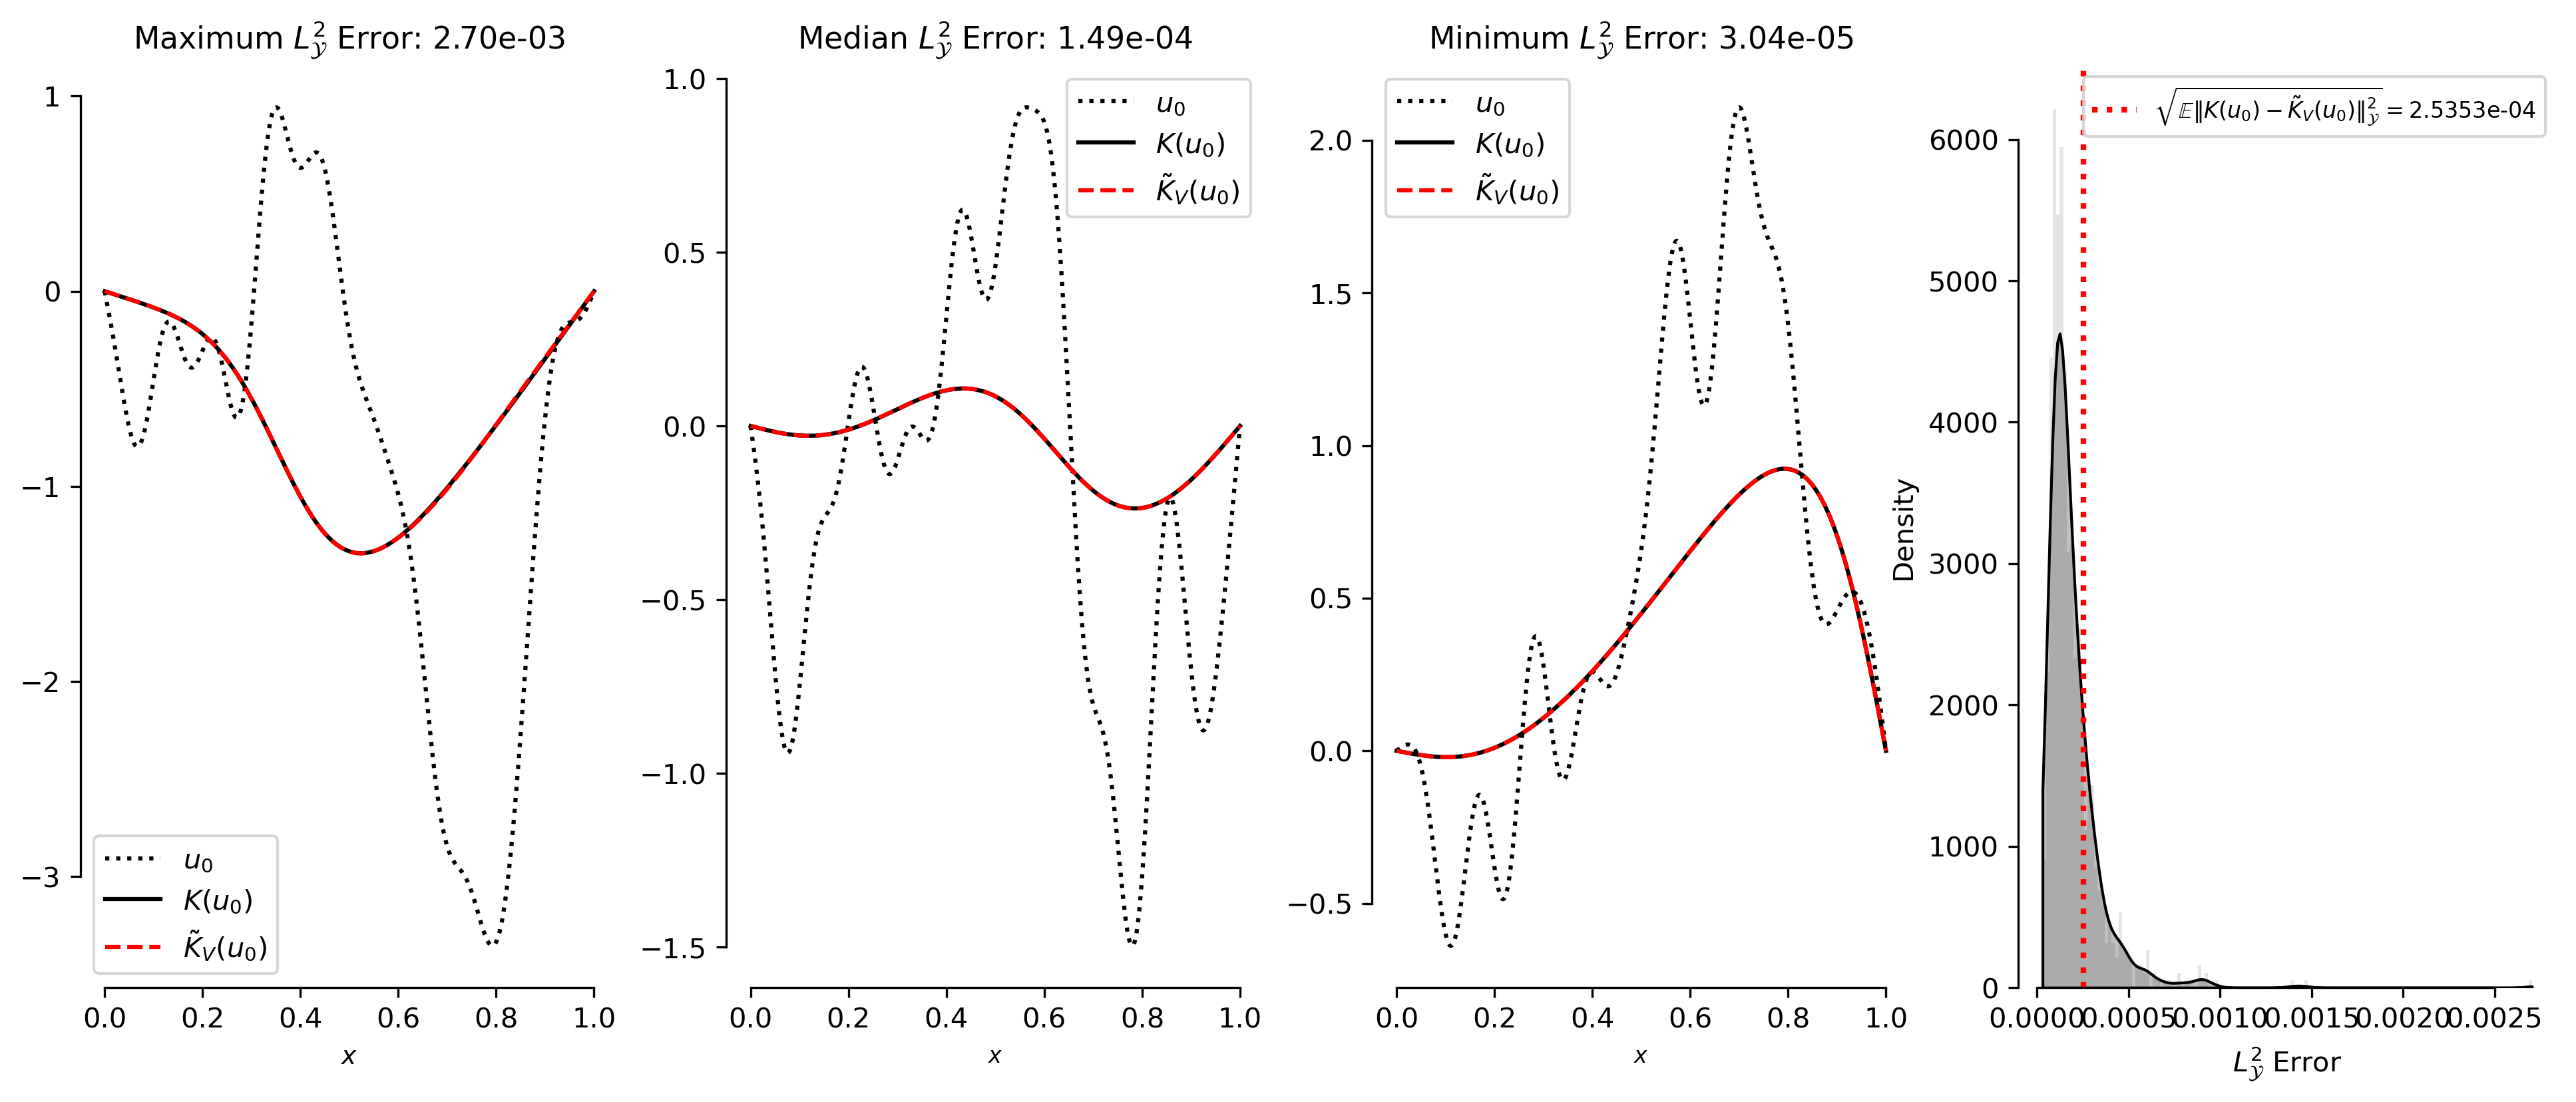

In [2]:
################################################################################################################
################################################################################################################
###                       Orthogonal Polynomial Operator Learning with Induced Sampling:
###                                Learn Solution Operator to Viscous Burgers Eqn                                       
################################################################################################################
################################################################################################################

################################################################################################################
###                                             Import Libraries:
################################################################################################################
import sys 
sys.path.insert(0,'../Modules/')
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from Block_WLS import Block_WLS
from Tensor_InducedSamp import Jacobi_Tensor_Induced_Sampling
from jacobi_sampling import jacobi_tensor_samp
from index_set import index_set
from pde_solvers import Viscous_Burgers_Spectral_Galerkin, sine_basis_vandermonde

################################################################################################################
#                                                 Parameters   
################################################################################################################

### Induced Sampling + Optimal Weights: 
induced = True                      # If true: input functions sampled optimally and LS weights changed accordingly

### Approximation space parameters
max_poly_degree =   10              # Maximum univariate degree of polynomials used to define operator basis 
input_mode_truncation = 20          # Truncated Dimension of Input Function Space 
output_mode_truncation = 150        # Truncated Dimension of Output Function Space 
hc_param = 60                       # Hyperbolic Cross Pruning Parameter 
M_test = 1000                       # Number of test samples
jacobi_params = [[(a**2),(a**2)]for a in range(input_mode_truncation)]

### PDE parameters & solver for Viscous Burgers
v = 0.1
T = 0.2                              # Final time for integration
dt = 0.001                          # Time step 
lift_dim = np.max([5*input_mode_truncation,output_mode_truncation])  # Lifted dimension for Galerkin solve; solution projected to output_mode_truncation                   
def pde_eval(input_data):
    M = input_data.shape[0]
    input_data_lifted = np.zeros([M, lift_dim])
    input_data_lifted[:, :input_mode_truncation] = input_data
    output_data = Viscous_Burgers_Spectral_Galerkin(v, dt, int(T/dt), input_data_lifted)[:, :output_mode_truncation]
    if not np.all(np.isfinite(np.linalg.norm(output_data, axis=1))):
        raise ValueError("Encountered inf/nan while solving PDE. Probably you want to decrease dt")
    return output_data

### Build Index Set

weights = np.linspace(1, 0.01, input_mode_truncation)
idx_set = index_set(input_mode_truncation, hc_param, max_index=max_poly_degree, weights=weights, max_size=10000, type="hc")    
N = idx_set.shape[0]
M = int(N * np.log(N))

################################################################################################################
#                                     Generate Train and Test Data
################################################################################################################ 

### Generate Training Data:
if induced:
    input_samples = input_samples = Jacobi_Tensor_Induced_Sampling(M, idx_set, jacobi_params, max_poly_degree)
else: 
    input_samples = jacobi_tensor_samp(jacobi_params, M)
output_samples = pde_eval(input_samples)


## Generate Testing Data:
test_input_samples = jacobi_tensor_samp(jacobi_params, M_test)
test_output_samples = pde_eval(test_input_samples)

################################################################################################################
#                                     Operator Learning
################################################################################################################

# Instantiate the operator learning object.
wls_operator = Block_WLS(jacobi_params, idx_set, input_samples, output_samples, induced)

# Apply the operator to test and train data.
approx_outputs = wls_operator.apply(input_samples)
test_approx_outputs = wls_operator.apply(test_input_samples)

################################################################################################################
#                           Plot Errors and Representative Samples
################################################################################################################
import seaborn as sns
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 300

# Compute errs 
test_errors = np.linalg.norm(test_approx_outputs - test_output_samples, axis = 1)
boch_test_err = np.sqrt(np.mean(test_errors**2))


# Plot representative samples and their error
x = np.linspace(0,1,1000)
Vi = np.sqrt(2)*sine_basis_vandermonde(x, input_mode_truncation)
Vo = np.sqrt(2)*sine_basis_vandermonde(x, output_mode_truncation)

max_samp = np.argmax(test_errors)
min_samp = np.argmin(test_errors)
med_samp = np.argmin(np.abs(np.median(test_errors) - test_errors))

fig,ax = plt.subplots(ncols = 4, figsize = (16,6))

ax[0].plot(x, Vi @ test_input_samples[max_samp].T, 'k:', label = r"$u_0$")
ax[0].plot(x, Vo @ test_output_samples[max_samp].T, 'k-', label = r"$K(u_0)$")
ax[0].plot(x, Vo @ test_approx_outputs[max_samp].T, 'r--', label = r"$\tilde{K}_V(u_0)$")
ax[0].set_title(r"Maximum $L^2_{\mathcal{Y}}$ Error: "+f"{np.max(test_errors):.2e}", fontsize = 11)
ax[0].set_xlabel(r"$x$", fontsize = 9)
ax[0].legend(loc = 'lower left', fontsize = 10)

ax[1].plot(x, Vi @ test_input_samples[med_samp].T, 'k:', label = r"$u_0$")
ax[1].plot(x, Vo @ test_output_samples[med_samp].T, 'k-', label = r"$K(u_0)$")
ax[1].plot(x, Vo @ test_approx_outputs[med_samp].T, 'r--', label = r"$\tilde{K}_V(u_0)$")
ax[1].set_title(r"Median $L^2_{\mathcal{Y}}$ Error: "+f"{np.median(test_errors):.2e}", fontsize = 11)
ax[1].set_xlabel(r"$x$", fontsize = 8)
ax[1].legend(loc = 'best',fontsize = 10)

ax[2].plot(x, Vi @ test_input_samples[min_samp].T, 'k:', label = r"$u_0$")
ax[2].plot(x, Vo @ test_output_samples[min_samp].T, 'k-', label = r"$K(u_0)$")
ax[2].plot(x, Vo @ test_approx_outputs[min_samp].T, 'r--', label = r"$\tilde{K}_V(u_0)$")
ax[2].set_title(r"Minimum $L^2_{\mathcal{Y}}$ Error: "+f"{np.min(test_errors):.2e}", fontsize = 11)
ax[2].set_xlabel(r"$x$", fontsize = 8)
ax[2].legend(loc = 'best',fontsize = 10)

ax[3].hist(test_errors, bins = int(M_test/7), density = True, color = 'black', alpha = 0.1)
sns.kdeplot(test_errors, fill = True, color = 'black', cut = 0, ax = ax[3])
ax[3].axvline(boch_test_err, linestyle = 'dotted', color = 'red', linewidth = 2, label = r"$\sqrt{\mathbb{E}\Vert K(u_0) - \tilde{K}_V(u_0)\Vert_{\mathcal{Y}}^2} = $"+f"{boch_test_err:.4e}")
ax[3].set_xlabel(r"$L^2_{\mathcal{Y}}$ Error", fontsize = 10)
ax[3].legend(loc = 'best', fontsize = 8)
sns.despine(trim = True)
plt.savefig("Plots/vB_err_dist")
plt.show()

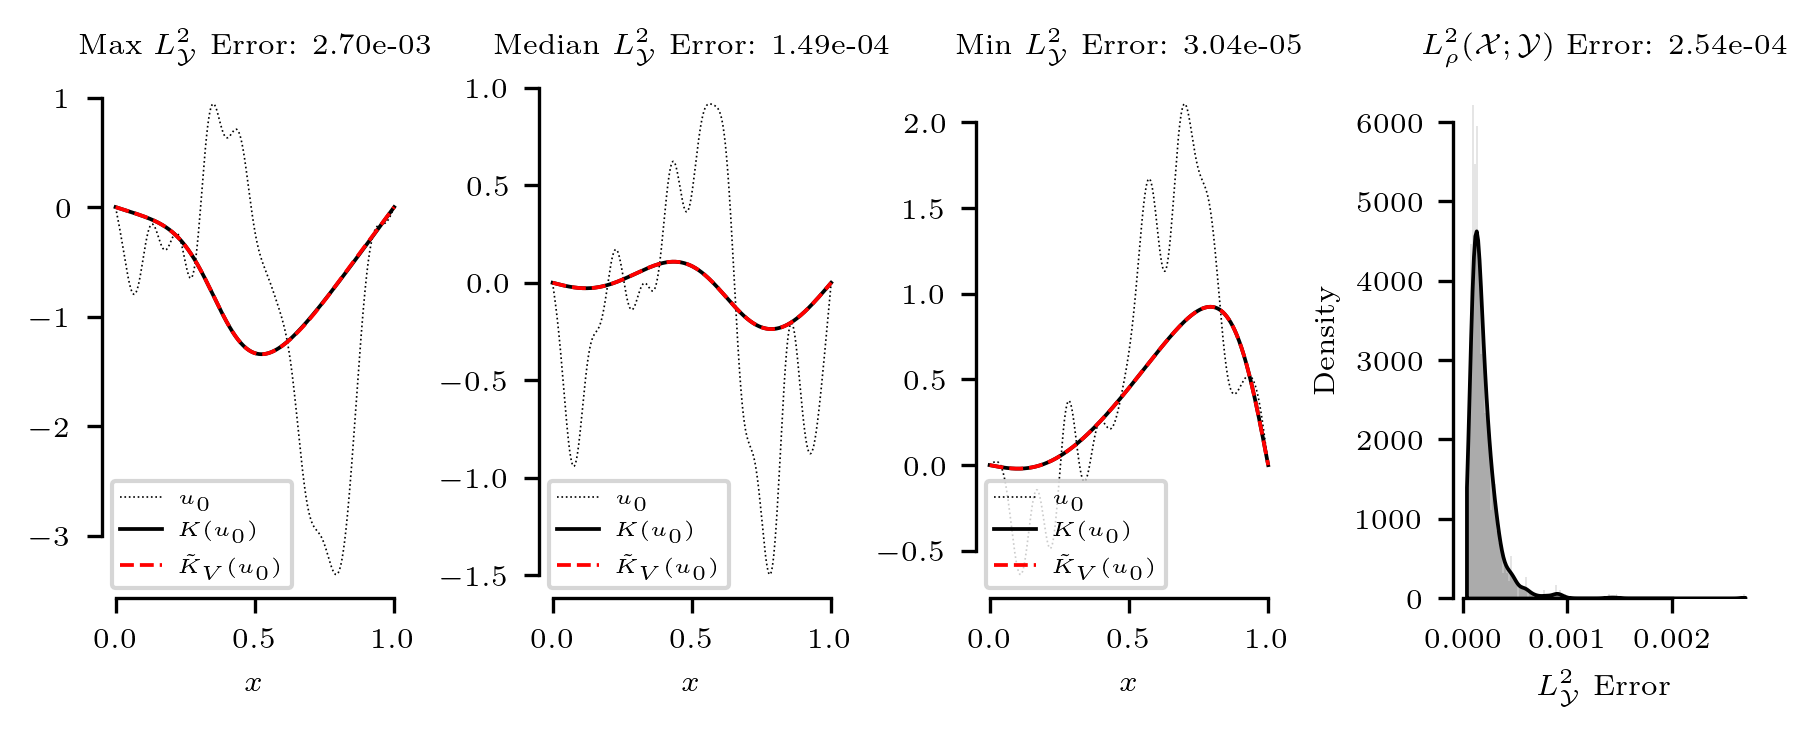

In [16]:
# General params 
plt.rcParams["font.size"] = 10
plt.rcParams["font.family"] = "Computer Modern"
plt.rcParams["text.usetex"] = True
plt.rcParams["text.latex.preamble"] = r"\usepackage{amsmath}\usepackage{amssymb}"
plt.rcParams["savefig.bbox"] = "tight"
plt.rcParams['savefig.transparent'] = True
plt.rcParams["savefig.format"] = "pdf"
mpl.rcParams['figure.dpi'] = 300

mpl.rcParams["pdf.fonttype"] = 42   # TrueType
mpl.rcParams["ps.fonttype"] = 42

# Set figure sizes 
textwidth_pt = 422.52252                     
pt_to_inch = 1.0 / 72.27
subfig_ratio = 1
fig_width = textwidth_pt * pt_to_inch   *subfig_ratio         
fig_height = fig_width * 0.4                     
# Font sizes
base = 7  # match LaTeX \normalsize
plt.rcParams["font.size"] = base
plt.rcParams["axes.labelsize"] = base       
plt.rcParams["axes.titlesize"] = base      
plt.rcParams["xtick.labelsize"] = base         
plt.rcParams["ytick.labelsize"] = base         
plt.rcParams["legend.fontsize"] = base -2        
# Markersizes
markersize_small = 1
linewidth_small = 0.4
markersize_large = 3
linewidth_large = 0.9


fig,ax = plt.subplots(ncols = 4, figsize = (fig_width,fig_height), layout = 'constrained')

ax[0].plot(x, Vi @ test_input_samples[max_samp].T, 'k:', label = r"$u_0$", linewidth = linewidth_small)
ax[0].plot(x, Vo @ test_output_samples[max_samp].T, 'k-', label = r"$K(u_0)$", linewidth = linewidth_large)
ax[0].plot(x, Vo @ test_approx_outputs[max_samp].T, 'r--', label = r"$\tilde{K}_V(u_0)$", linewidth = linewidth_large)
ax[0].set_title(r"Max $L^2_{\mathcal{Y}}$ Error: "+f"{np.max(test_errors):.2e}")
ax[0].set_xlabel(r"$x$")
ax[0].legend(loc = 'lower left')

ax[1].plot(x, Vi @ test_input_samples[med_samp].T, 'k:', label = r"$u_0$", linewidth = linewidth_small)
ax[1].plot(x, Vo @ test_output_samples[med_samp].T, 'k-', label = r"$K(u_0)$", linewidth = linewidth_large)
ax[1].plot(x, Vo @ test_approx_outputs[med_samp].T, 'r--', label = r"$\tilde{K}_V(u_0)$", linewidth = linewidth_large)
ax[1].set_title(r"Median $L^2_{\mathcal{Y}}$ Error: "+f"{np.median(test_errors):.2e}")
ax[1].set_xlabel(r"$x$")
ax[1].legend(loc = 'best')

ax[2].plot(x, Vi @ test_input_samples[min_samp].T, 'k:', label = r"$u_0$", linewidth = linewidth_small)
ax[2].plot(x, Vo @ test_output_samples[min_samp].T, 'k-', label = r"$K(u_0)$", linewidth = linewidth_large)
ax[2].plot(x, Vo @ test_approx_outputs[min_samp].T, 'r--', label = r"$\tilde{K}_V(u_0)$", linewidth = linewidth_large)
ax[2].set_title(r"Min $L^2_{\mathcal{Y}}$ Error: "+f"{np.min(test_errors):.2e}")
ax[2].set_xlabel(r"$x$")
ax[2].legend(loc = 'lower left')

ax[3].hist(test_errors, bins = int(M_test/7), density = True, color = 'black', alpha = 0.1)
sns.kdeplot(test_errors, fill = True, color = 'black', cut = 0, ax = ax[3], linewidth = linewidth_large)
#ax[3].axvline(boch_test_err, linestyle = 'dotted', color = 'red', linewidth = 2, label = r"$\sqrt{\mathbb{E}\Vert K(u_0) - \tilde{K}_V(u_0)\Vert_{\mathcal{Y}}^2} = $"+f"{boch_test_err:.4e}")
ax[3].set_xlabel(r"$L^2_{\mathcal{Y}}$ Error")
ax[3].set_title(r"$L^2_\rho(\mathcal{X}; \mathcal{Y})$ Error: " + f"{boch_test_err:.2e}")
#ax[3].legend(loc = 'best')
sns.despine(trim = True)
plt.savefig("Plots/vB_err_dist.pdf")
plt.show()